In [1]:

import os
import zipfile


zip_path = r'D:\Python workspace\dataset.zip' 
extract_path = 'data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


print("Folders inside extracted dataset:")
print(os.listdir(extract_path))


Dataset extracted to: data/
Folders inside extracted dataset:
['brain_tumor_dataset', 'no', 'yes']


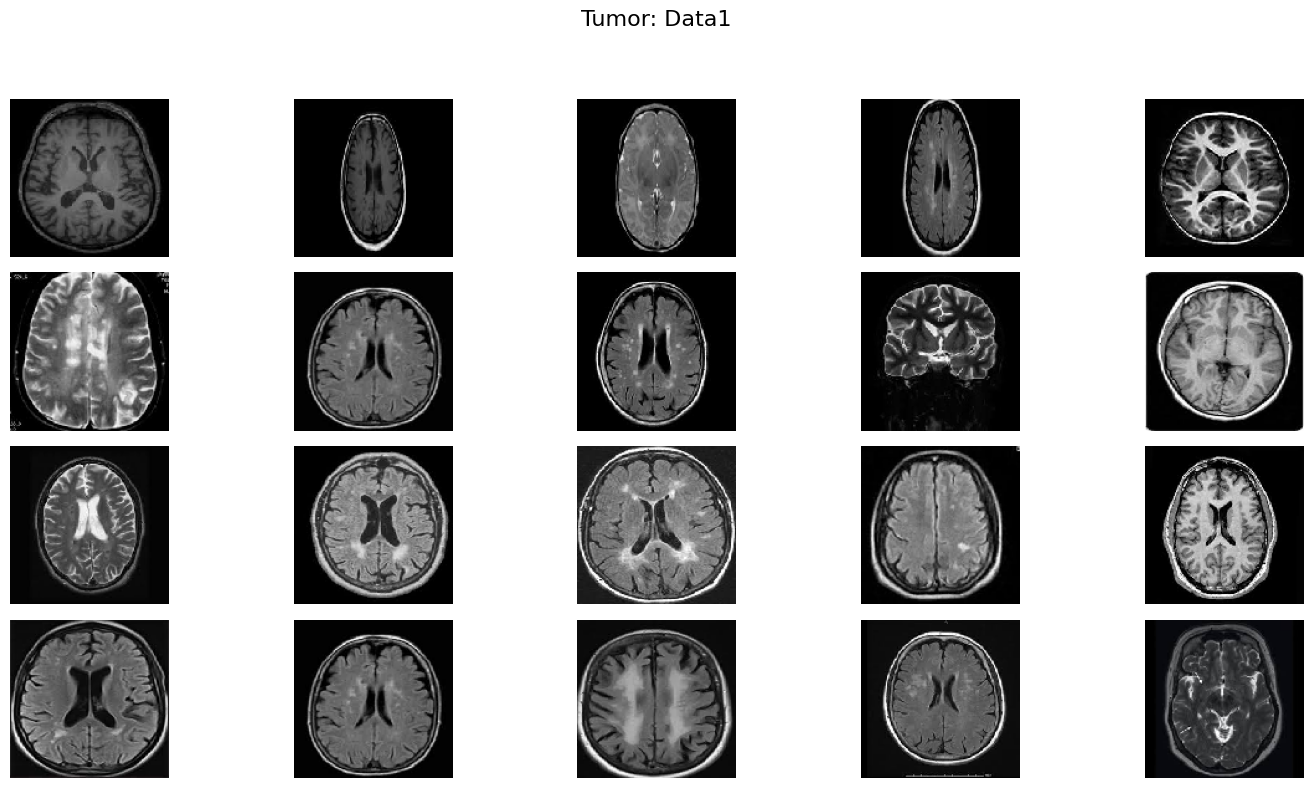

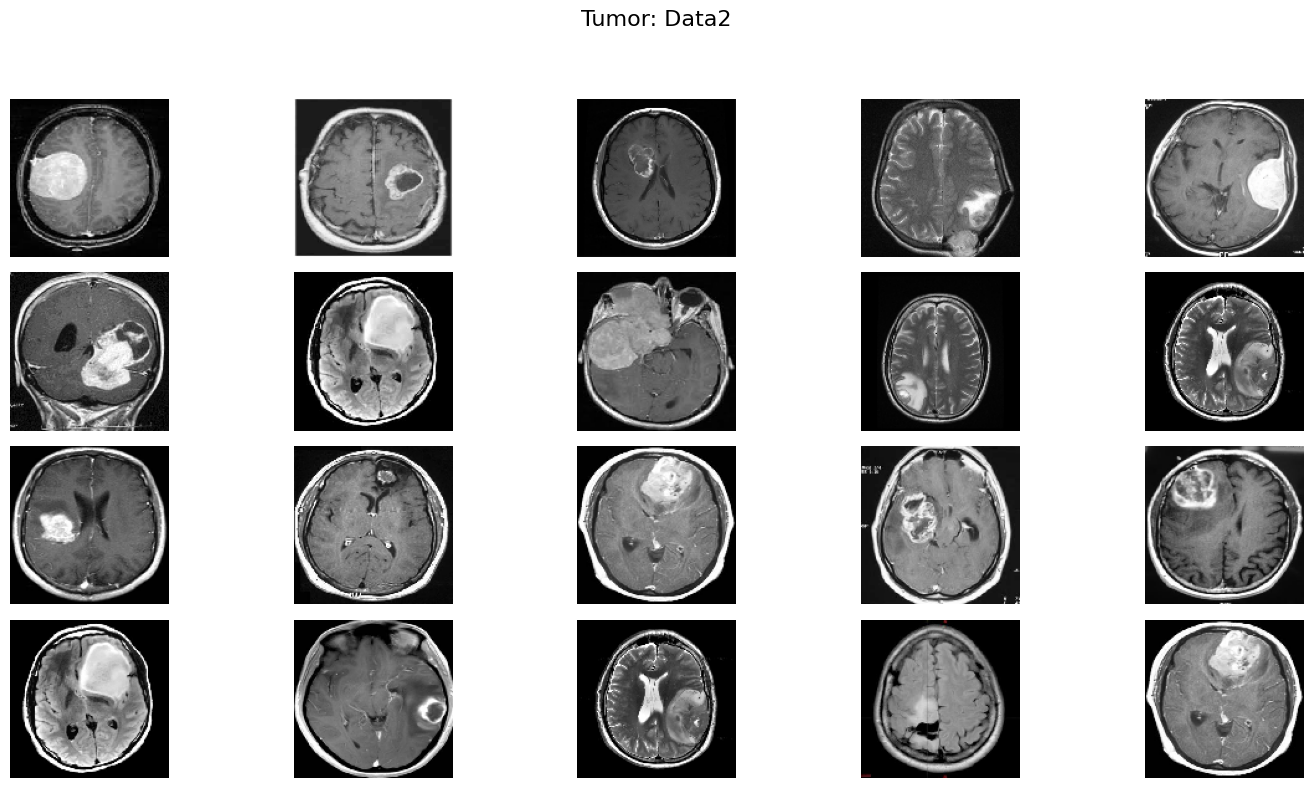

In [2]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def plot_mri_grid(class_dir, label, n_images=20):
    img_files = [os.path.join(class_dir, fname) for fname in os.listdir(class_dir) if fname.endswith('.jpg') or fname.endswith('.png')]
    plt.figure(figsize=(15,8))
    plt.suptitle(f"Tumor: {label}", fontsize=16)
    for i, img_path in enumerate(img_files[:n_images]):
        plt.subplot(4, 5, i+1)
        img = image.load_img(img_path, target_size=(128,128))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Tumor NO grid
plot_mri_grid('data/no', 'Data1', n_images=20)   # Adjust path as per your folder structure

# Tumor YES grid
plot_mri_grid('data/yes', 'Data2', n_images=20)


In [3]:
import sys
print(sys.executable)

d:\Python workspace\venv\Scripts\python.exe


In [4]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = 'data/brain_tumor_dataset'

# Image size and batch size
img_size = 224
batch_size = 32

# ImageDataGenerator with augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% data validation
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator without augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Training samples: 203
Validation samples: 50


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom classification layers on top
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history_vgg16  = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 67s 9s/step - accuracy: 0.4926 - loss: 3.1080 - val_accuracy: 0.4000 - val_loss: 0.6936
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 68s 10s/step - accuracy: 0.4532 - loss: 0.6945 - val_accuracy: 0.6200 - val_loss: 0.6556
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 9s/step - accuracy: 0.6059 - loss: 0.6561 - val_accuracy: 0.7600 - val_loss: 0.6199
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 9s/step - accuracy: 0.6897 - loss: 0.6186 - val_accuracy: 0.6200 - val_loss: 0.5778
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.6207 - loss: 0.6010 - val_accuracy: 0.8000 - val_loss: 0.5430
Epoch 6/10
2/7 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7860 - loss: 0.5875 

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# VGG16 base model load with pretrained weights 
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model.trainable = False

# custom classification layers add
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Model compile karein with loss and optimizer
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_vgg16  = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.5222 - loss: 4.7341 - val_accuracy: 0.6200 - val_loss: 0.6607
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6108 - loss: 0.6598 - val_accuracy: 0.6200 - val_loss: 0.6273
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.6108 - loss: 0.6464 - val_accuracy: 0.6200 - val_loss: 0.6017
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.6305 - loss: 0.6289 - val_accuracy: 0.6800 - val_loss: 0.5802
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.6305 - loss: 0.6120 - val_accuracy: 0.6800 - val_loss: 0.5656
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.6897 - loss: 0.5997 - val_accuracy: 0.8000 - val_loss: 0.5608
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.6995 - loss: 0.5862 - val_accuracy: 0.7000 - val_loss: 0.5414
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.6798 - loss: 0.5749 - val_accuracy: 0.8000 - val_loss: 0.5341
Epoch 9/

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step
              precision    recall  f1-score   support

    No Tumor       0.91      0.53      0.67        19
       Tumor       0.77      0.97      0.86        31

    accuracy                           0.80        50
   macro avg       0.84      0.75      0.76        50
weighted avg       0.82      0.80      0.78        50



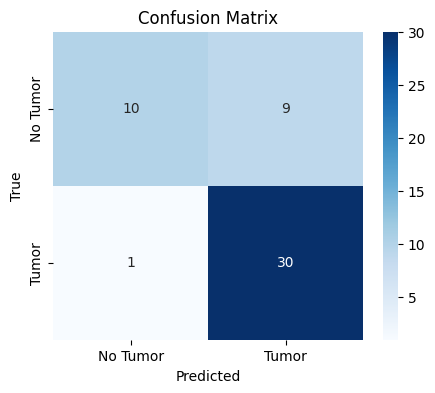

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict values for validation set
val_generator.reset()
preds = model.predict(val_generator)
pred_labels = (preds > 0.5).astype(int)

true_labels = val_generator.classes

# Classification report
print(classification_report(true_labels, pred_labels, target_names=['No Tumor', 'Tumor']))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


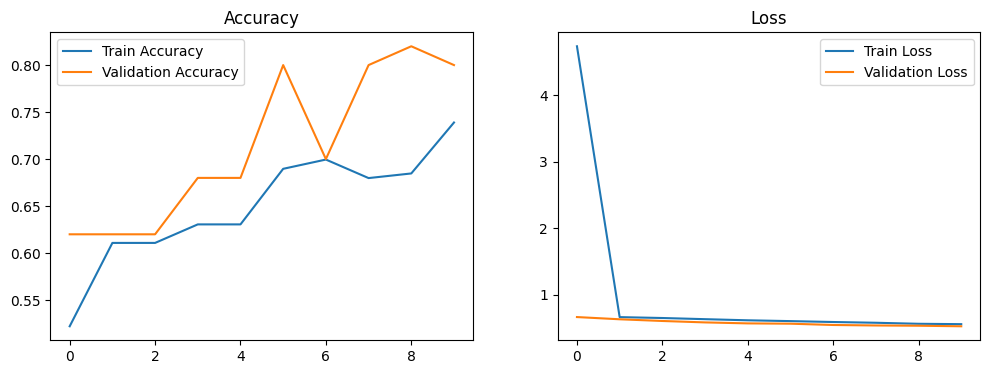

In [ ]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_vgg16 .history ['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16 .history ['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history_vgg16 .history ['loss'], label='Train Loss')
plt.plot(history_vgg16 .history ['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input

def get_img_array(img_path, size):
    img = image.load_img(img_path, target_size=size)
    array = image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return preprocess_input(array)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(img_path, heatmap, alpha=0.4):
    img = image.load_img(img_path)
    img = image.img_to_array(img)
    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap("jet")
    heatmap_colored = jet(heatmap)[:, :, :3]
    heatmap_colored = np.uint8(255 * heatmap_colored)
    # Superimpose the heatmap on original image
    superimposed_img = cv2.addWeighted(img.astype(np.uint8), 1 - alpha, heatmap_colored, alpha, 0)
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.axis('off')
    plt.show()


d:\Python workspace\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_26']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_19804\854732830.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


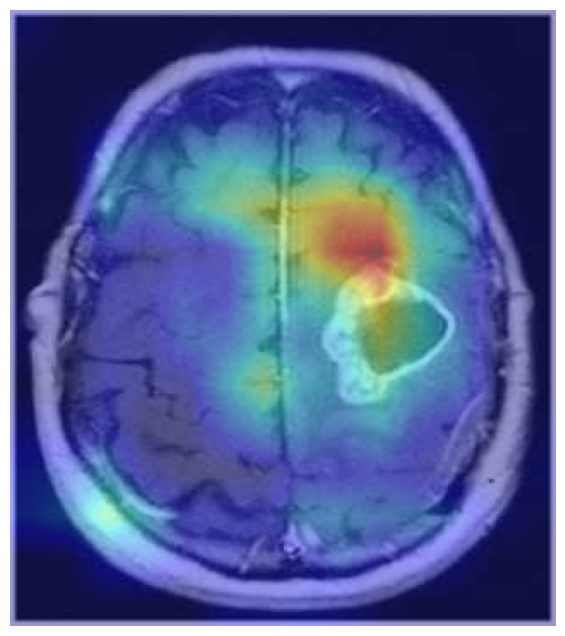

In [ ]:
img_path = 'data/yes/Y10.jpg'
img_size = (224, 224)
last_conv_layer_name = 'block5_conv3'
img_array = get_img_array(img_path, img_size)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
overlay_heatmap(img_path, heatmap)


In [ ]:
import os

print(os.listdir())  # current directory ke sab files dikhayega


['data', 'dataset', 'dataset.zip', 'final_year_project1.ipynb', 'try.py', 'Untitled-1.py', 'venv']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step


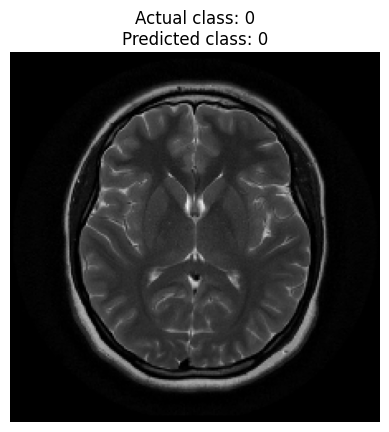

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


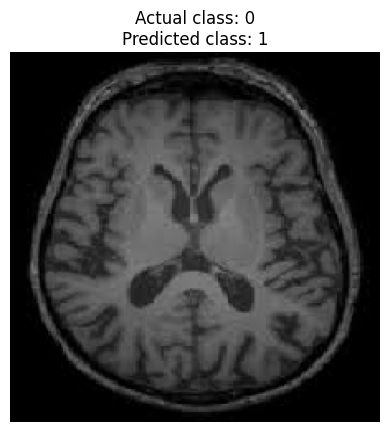

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


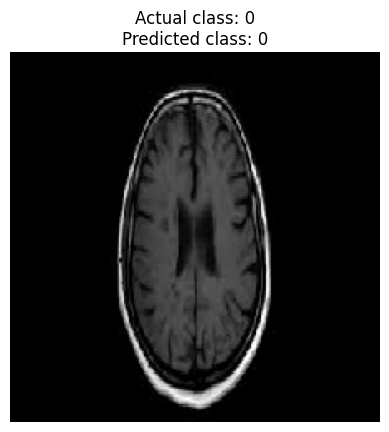

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


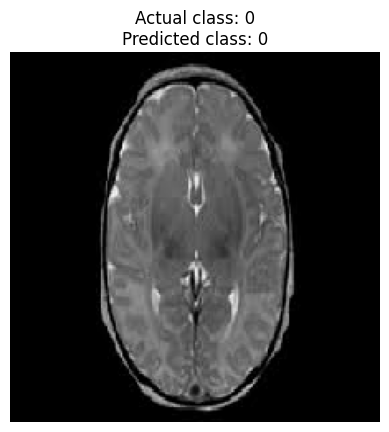

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


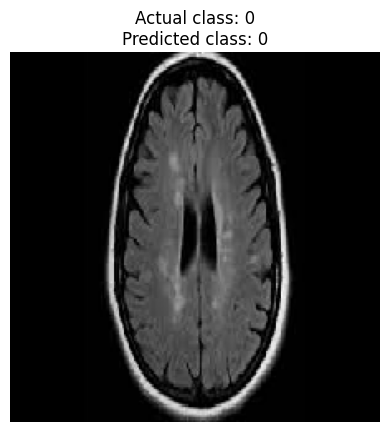

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Example - verify on n images from validation set
n = 5  
val_generator.reset()
img_paths = [val_generator.filepaths[i] for i in range(n)]
true_labels = [val_generator.classes[i] for i in range(n)]
class_names = ['No Tumor', 'Tumor']

for i in range(n):
    img = image.load_img(img_paths[i], target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0

    pred = model.predict(x)
    pred_class = int(pred[0][0] > 0.5)

    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'Actual class: {true_labels[i]}\nPredicted class: {pred_class}')
    plt.show()


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the ResNet50 base model (use imagenet weights, no top layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model
base_model.trainable = False

# Custom classification layers
x = GlobalAveragePooling2D()(base_model.output)  # GlobalAveragePooling (preferred for ResNet)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Training (use same train_generator and val_generator as before)
history_resnet50 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5714 - loss: 0.7390 - val_accuracy: 0.6400 - val_loss: 0.6484
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6601 - loss: 0.6605 - val_accuracy: 0.6200 - val_loss: 0.6313
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6355 - loss: 0.6389 - val_accuracy: 0.7000 - val_loss: 0.6011
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6502 - loss: 0.6302 - val_accuracy: 0.6800 - val_loss: 0.5915
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6798 - loss: 0.6318 - val_accuracy: 0.6800 - val_loss: 0.6170
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6650 - loss: 0.6247 - val_accuracy: 0.6600 - val_loss: 0.5744
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6601 - loss: 0.6316 - val_accuracy: 0.6400 - val_loss: 0.5655
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6995 - loss: 0.601

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history_resnet50 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4729 - loss: 0.7698 - val_accuracy: 0.3800 - val_loss: 0.8469
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5616 - loss: 0.7532 - val_accuracy: 0.6200 - val_loss: 0.7112
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6404 - loss: 0.6665 - val_accuracy: 0.6400 - val_loss: 0.6742
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6404 - loss: 0.6450 - val_accuracy: 0.6400 - val_loss: 0.6391
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6404 - loss: 0.6329 - val_accuracy: 0.6200 - val_loss: 0.6196
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6552 - loss: 0.6368 - val_accuracy: 0.6000 - val_loss: 0.6076
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6897 - loss: 0.6245 - val_accuracy: 0.6400 - val_loss: 0.5975
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6847 - loss: 0.6282 - val_accuracy: 0.6200 - val_loss: 0.5940
Epoch 9/

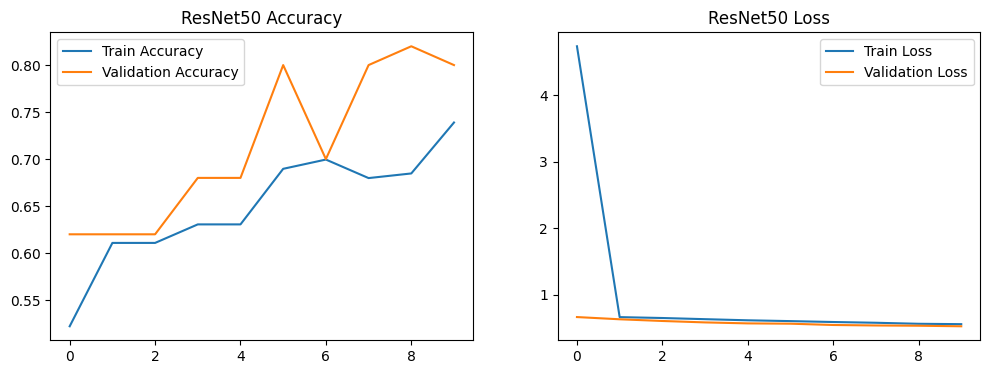

In [ ]:
import matplotlib.pyplot as plt

# Accuracy and loss plots
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_vgg16 .history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16 .history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_vgg16 .history['loss'], label='Train Loss')
plt.plot(history_vgg16 .history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.legend()
plt.show()


1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/stepWARNING:tensorflow:5 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001B3BF8BEB60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
              precision    recall  f1-score   support

    No Tumor       0.55      0.63      0.59        19
       Tumor       0.75      0.68      0.71        31

    accuracy                           

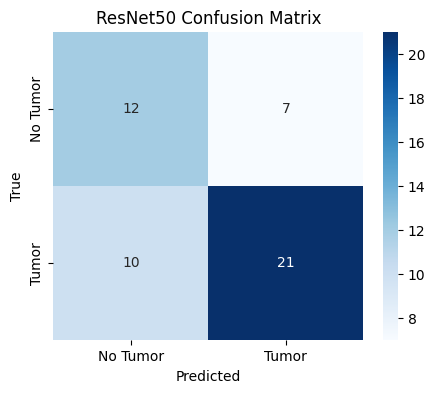

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

val_generator.reset()
preds = model.predict(val_generator)
pred_labels = (preds > 0.5).astype(int)
true_labels = val_generator.classes

print(classification_report(true_labels, pred_labels, target_names=['No Tumor', 'Tumor']))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet50 Confusion Matrix')
plt.show()


d:\Python workspace\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_236']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_19804\854732830.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


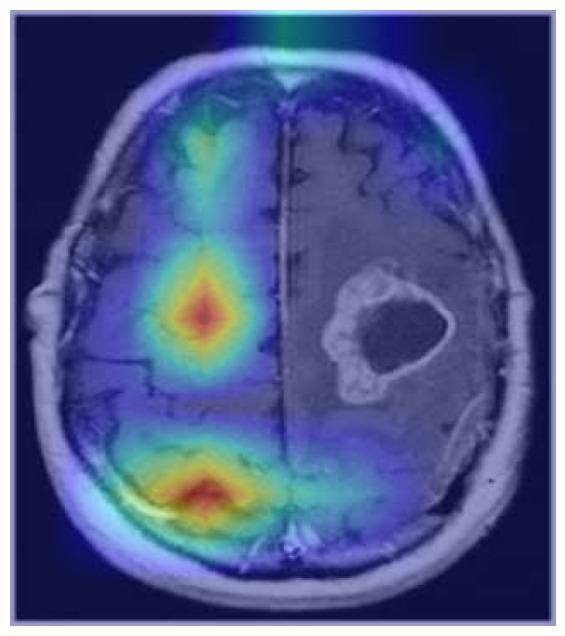

In [ ]:
img_path = 'data/yes/Y10.jpg'
img_size = (224, 224)
last_conv_layer_name = 'conv5_block3_out'  # ResNet50 last conv layer

img_array = get_img_array(img_path, img_size)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
overlay_heatmap(img_path, heatmap)


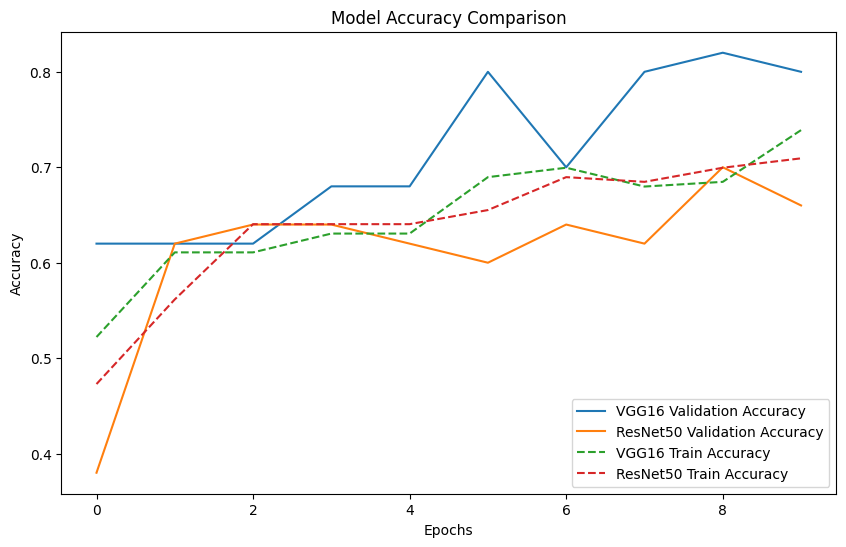

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history_vgg16.history['val_accuracy'], label='VGG16 Validation Accuracy')
plt.plot(history_resnet50.history['val_accuracy'], label='ResNet50 Validation Accuracy')
plt.plot(history_vgg16.history['accuracy'], linestyle='--', label='VGG16 Train Accuracy')
plt.plot(history_resnet50.history['accuracy'], linestyle='--', label='ResNet50 Train Accuracy')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


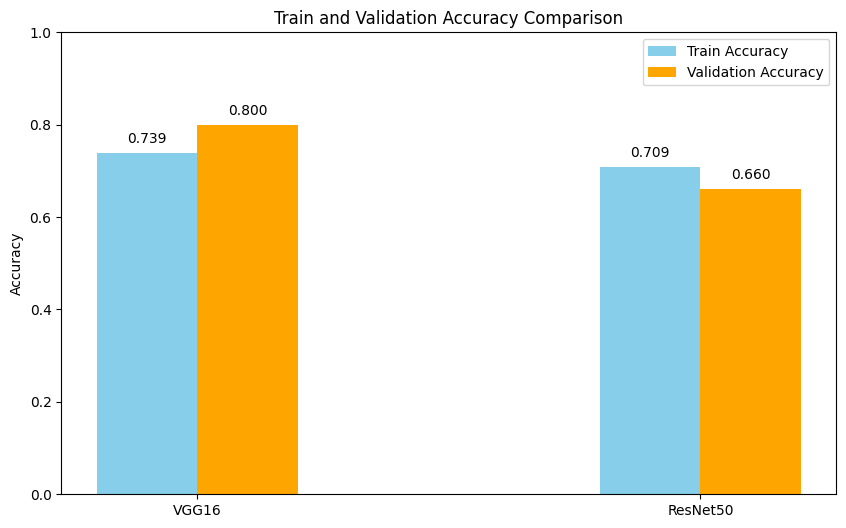

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Final train and validation accuracies (replace with your actual values)
train_acc_vgg16 = history_vgg16.history['accuracy'][-1]
val_acc_vgg16 = history_vgg16.history['val_accuracy'][-1]
train_acc_resnet50 = history_resnet50.history['accuracy'][-1]
val_acc_resnet50 = history_resnet50.history['val_accuracy'][-1]

models = ['VGG16', 'ResNet50']
train_accuracies = [train_acc_vgg16, train_acc_resnet50]
val_accuracies = [val_acc_vgg16, val_acc_resnet50]

x = np.arange(len(models))  # label locations
width = 0.2  # width of bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, val_accuracies, width, label='Validation Accuracy', color='orange')

ax.set_ylabel('Accuracy')
ax.set_title('Train and Validation Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0,1)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

rarenet_model = Sequential()

# Block 1
rarenet_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
rarenet_model.add(BatchNormalization())
rarenet_model.add(MaxPooling2D(2,2))

# Block 2
rarenet_model.add(Conv2D(64,(3,3),activation='relu'))
rarenet_model.add(BatchNormalization())
rarenet_model.add(MaxPooling2D(2,2))

# Block 3
rarenet_model.add(Conv2D(128,(3,3),activation='relu'))
rarenet_model.add(BatchNormalization())
rarenet_model.add(MaxPooling2D(2,2))

# Block 4
rarenet_model.add(Conv2D(256,(3,3),activation='relu'))
rarenet_model.add(BatchNormalization())
rarenet_model.add(MaxPooling2D(2,2))

# Flatten
rarenet_model.add(Flatten())

# Dense layers
rarenet_model.add(Dense(256,activation='relu'))
rarenet_model.add(Dropout(0.5))

rarenet_model.add(Dense(128,activation='relu'))
rarenet_model.add(Dropout(0.3))

# Output
rarenet_model.add(Dense(1,activation='sigmoid'))

rarenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rarenet_model.summary() 

d:\Python workspace\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,860,801 (37.62 MB)

 Trainable params: 9,859,841 (37.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history_rarenet = rarenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.5764 - loss: 3.7998 - val_accuracy: 0.6000 - val_loss: 0.6187
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6355 - loss: 3.6760 - val_accuracy: 0.7200 - val_loss: 0.5099
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6207 - loss: 3.5682 - val_accuracy: 0.6200 - val_loss: 0.9610
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5813 - loss: 3.0252 - val_accuracy: 0.6200 - val_loss: 1.3099
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6404 - loss: 2.3395 - val_accuracy: 0.6200 - val_loss: 2.1575
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6453 - loss: 3.1093 - val_accuracy: 0.6200 - val_loss: 2.3853
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.6108 - loss: 3.5034 - val_accuracy: 0.6200 - val_loss: 0.9628
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6502 - loss: 3.3922 - val_accuracy: 0.6800 - val_loss: 0.7298
Epoch 9/

In [ ]:
preds = rarenet_model.predict(val_generator)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step


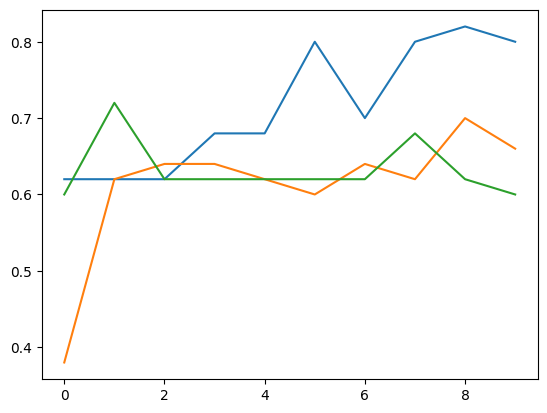

In [ ]:
plt.plot(history_vgg16.history['val_accuracy'], label='VGG16')
plt.plot(history_resnet50.history['val_accuracy'], label='ResNet50')
plt.plot(history_rarenet.history['val_accuracy'], label='RareNet')

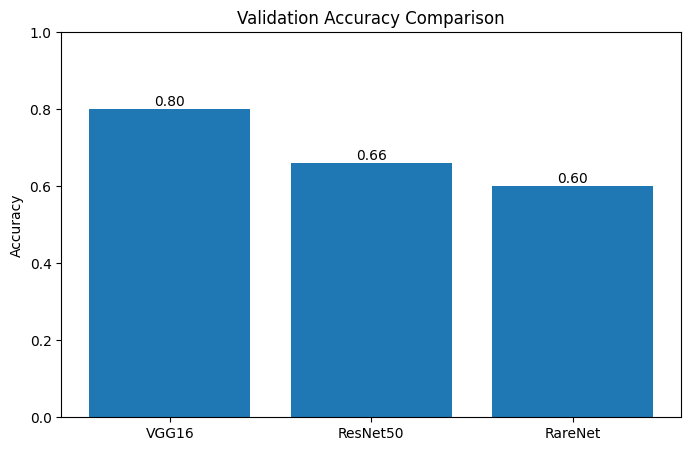

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get final validation accuracy of each model
val_acc_vgg16 = history_vgg16.history['val_accuracy'][-1]
val_acc_resnet50 = history_resnet50.history['val_accuracy'][-1]
val_acc_rarenet = history_rarenet.history['val_accuracy'][-1]

models = ['VGG16', 'ResNet50', 'RareNet']
accuracies = [val_acc_vgg16, val_acc_resnet50, val_acc_rarenet]

# Plot bar graph
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

plt.show()

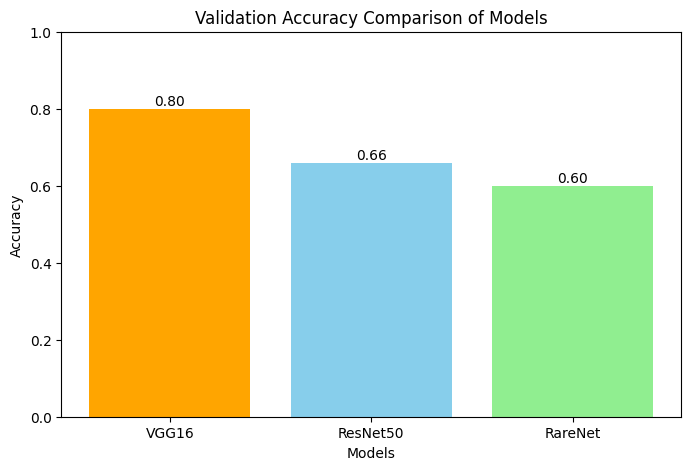

In [ ]:
import matplotlib.pyplot as plt

# Get final validation accuracy
val_acc_vgg16 = history_vgg16.history['val_accuracy'][-1]
val_acc_resnet50 = history_resnet50.history['val_accuracy'][-1]
val_acc_rarenet = history_rarenet.history['val_accuracy'][-1]

models = ['VGG16', 'ResNet50', 'RareNet']
accuracies = [val_acc_vgg16, val_acc_resnet50, val_acc_rarenet]

colors = ['orange', 'skyblue', 'lightgreen']

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, color=colors)

plt.title("Validation Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0,1)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom')

plt.show()